In [1]:
import sys
print(sys.executable)

/home/jupyter-deu225/.conda/envs/DSCI-498-main/bin/python


In [2]:
# ────────────────  Cell: Load & run local modules ────────────────
%load_ext autoreload
%autoreload 2

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

%run ./band_indices.py
%run ./landsat_data.py
%run ./sentinel_tiff.py
# %run ./dcgan.py

print("All local scripts executed successfully.")


/home/jupyter-deu225/.conda/envs/DSCI-498-main/lib/python3.12/site-packages/optuna/study/_optimize.py:20: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from optuna import progress_bar as pbar_module
/home/jupyter-deu225/.conda/envs/DSCI-498-main/lib/python3.12/site-packages/pystac_client/item_search.py:881: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


Number of Landsat-8 scenes available: 5
Saved GeoTIFF: Landsat_Non_Thermal.tiff
Saved GeoTIFF: Landsat_Thermal.tiff
Number of Sentinel-2 scenes available: 7
Saved GeoTIFF: Sentinel_Data.tiff
All local scripts executed successfully.


In [23]:
# ----- Visualization & Plotting -----
%load_ext cuml.accel
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
    
# ----- Data Science & Machine Learning -----
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import optuna
import tensorflow as tf
from tensorflow.keras import layers, models
    
# ----- XGBoost -----
import xgboost as xgb

# ----- Planetary Computer / STAC & Geospatial -----
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
import rasterio
from rasterio.transform import from_bounds as rasterio_from_bounds
from pyproj import Proj, CRS, Transformer
import pystac_client
import planetary_computer
from odc.stac import stac_load
import stackstac

# ----- Additional tools -----
from tqdm import tqdm
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import sentinel_tiff as st
import band_indices as bi
print("Environment setup and imports completed successfully.")

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel
Environment setup and imports completed successfully.


## Response Variable

In [4]:
# Load the training data from CSV file and display the first few rows
ground_df = pd.read_csv("Dataset/Training_data_uhi_index_2025-02-18.csv")
print(ground_df.head())

   Longitude   Latitude          datetime  UHI Index
0 -73.909167  40.813107  24-07-2021 15:53   1.030289
1 -73.909187  40.813045  24-07-2021 15:53   1.030289
2 -73.909215  40.812978  24-07-2021 15:53   1.023798
3 -73.909242  40.812908  24-07-2021 15:53   1.023798
4 -73.909257  40.812845  24-07-2021 15:53   1.021634


## Predictor Variables

In [5]:
import pandas as pd
import numpy as np
import rioxarray as rxr
import rasterio
from tqdm import tqdm
from pyproj import Transformer
from pathlib import Path
import cupy as cp
import numba as nb

# ---------------- Shared ----------------
def read_csv_coords(csv_path):
    df = pd.read_csv(csv_path)
    return df["Latitude"].values, df["Longitude"].values, df

def get_transformer_np(tiff_crs):
    # Still CPU-based
    return Transformer.from_crs("EPSG:4326", tiff_crs, always_xy=True)

# ---------------- GPU accelerated pixel extractor ----------------
@nb.njit(parallel=True)
def extract_band_values_gpu(bands, xs, ys, transform, height, width, nodata_val=-9999):
    n_points = xs.shape[0]
    n_bands = bands.shape[0]
    results = np.full((n_points, n_bands), nodata_val, dtype=np.float32)

    for i in nb.prange(n_points):
        x = xs[i]
        y = ys[i]

        px = int((x - transform[0]) / transform[1])
        py = int((y - transform[3]) / transform[5])

        if 0 <= px < width and 0 <= py < height:
            for b in range(n_bands):
                results[i, b] = bands[b, py, px]
    return results

# ---------------- Main Raster Mapping ----------------
def map_raster_to_coords(tiff_path, csv_path, band_names=None, selected_bands=None):
    """
    Map GeoTIFF band values onto CSV-listed lat/lon points.
    """
    # 1) Load raster
    data = rxr.open_rasterio(tiff_path, masked=True)
    crs = data.rio.crs

    # 2) Read CSV
    pts = pd.read_csv(csv_path)
    lats = pts['Latitude'].values
    lons = pts['Longitude'].values

    # 3) Select bands
    all_bands = data.band.values.tolist()
    bands = selected_bands if selected_bands else all_bands
    names = band_names if band_names else [f"B{b:02d}" for b in bands]

    # 4) Project coordinates to raster CRS
    transformer = Transformer.from_crs("EPSG:4326", crs, always_xy=True)
    xs, ys = transformer.transform(lons, lats)

    # 5) Extract band values at each point
    records = []
    for x, y in tqdm(zip(xs, ys), total=len(xs), desc="Mapping raster values"):
        vals = [ data.sel(band=b, x=x, y=y, method="nearest").values.item() for b in bands ]
        records.append(vals)

    return pd.DataFrame(records, columns=names)


In [6]:
csv_path = "Dataset/Training_data_uhi_index_2025-02-18.csv"

sentinel_df = map_raster_to_coords(
    "Sentinel_Data.tiff", 
    csv_path,
    selected_bands = [1,2,3,4,5,6,7],
    band_names     = ["B01","B02","B03","B04","B08","B11","B12"]
)

thermal_df = map_raster_to_coords(
    "Landsat_Thermal.tiff",
    csv_path,
    # We only have one band in this TIFF, so pick index 0 (first band)
    selected_bands = [0],
    # And call it “lwir11”
    band_names     = ["lwir11"]
)

print(sentinel_df.head())
print(thermal_df.head())

Mapping raster values: 100%|██████████| 11229/11229 [00:17<00:00, 645.05it/s]

     B01    B02     B03     B04     B08     B11     B12
0  825.0  990.0  1144.0  1172.0  1830.0  1788.0  1540.0
1  825.0  990.0  1144.0  1172.0  1830.0  1788.0  1540.0
2  825.0  622.0   785.0   744.0  2318.0  1566.0  1170.0
3  825.0  619.0   750.0   738.0  2302.0  1566.0  1170.0
4  825.0  556.0   758.0   660.0  2280.0  1658.0  1240.0
      lwir11
0  42.345172
1  42.345172
2  41.442815
3  41.442815
4  41.152283





### Extracting Band Values from the GeoTIFF Image


In [7]:
# Calculate NDVI (Normalized Difference Vegetation Index) and handle division by zero by replacing infinities with NaN.
# See the Sentinel-2 sample notebook for more information about the NDVI index

sentinel_df, idx_dict = bi.compute_indices(sentinel_df)
sentinel_df = bi.classify_water_two_step(sentinel_df, thresh_nsh=0, thresh_sh=0, col_name="is_water")


## Joining the predictor variables and response variables
Now that we have extracted our predictor variables, we need to join them onto the response variable . We use the function <i><b>combine_two_datasets</b></i> to combine the predictor variables and response variables.The <i><b>concat</b></i> function from pandas comes in handy here.

In [8]:
# Combine two datasets vertically (along columns) using pandas concat function.
def combine_two_datasets(dataset1,dataset2):
    '''
    Returns a  vertically concatenated dataset.
    Attributes:
    dataset1 - Dataset 1 to be combined 
    dataset2 - Dataset 2 to be combined
    '''
    
    data = pd.concat([dataset1,dataset2], axis=1)
    return data

In [9]:
# Combining ground data and final data into a single dataset.
final_data = combine_two_datasets(sentinel_df, thermal_df)
uhi_data = combine_two_datasets(ground_df,final_data)
uhi_data.head()
# Save the combined UHI DataFrame to CSV and provide a download link
try:
    uhi_data.to_csv('uhi_data.csv', index=False)
    from IPython.display import FileLink, display
    display(FileLink('uhi_data.csv'))
except NameError:
    print("Error: 'uhi_data' not found. Please run the cell that combines `ground_df` and `final_data` first.")


/home/jupyter-deu225/DSCI-498-main/uhi_data.csv

## Removing duplicates
Identical or duplicate entries are removed based on specific columns, in our case [ 'B01','B04','B06','B08','NDVI']. This ensures that the dataset is not biased or skewed by repetitive data, allowing the model to train on unique, relevant observations.

In [10]:
# Remove duplicate rows from the DataFrame based on specified columns and keep the first occurrence
columns_to_check = ["B01", "B02", "B03", "B04", "B08", 
        "B11", "B12", "ARVI", "ABEI", 
        "AWEI_nsh", "AWEI_sh", "lwir11"]
for col in columns_to_check:
    # Check if the value is a numpy array and has more than one dimension
    uhi_data[col] = uhi_data[col].apply(lambda x: tuple(x) if isinstance(x, np.ndarray) and x.ndim > 0 else x)

# Now remove duplicates
uhi_data = uhi_data.drop_duplicates(subset=columns_to_check, keep='first')
uhi_data.head()



,Longitude,Latitude,datetime,UHI Index,B01,B02,B03,B04,B08,B11,B12,ARVI,ABEI,AWEI_nsh,AWEI_sh,classification,is_water,lwir11
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,825.0,990.0,1144.0,1172.0,1830.0,1788.0,1540.0,0.092177,319.290,-7268.5,-1962.0,3,0,42.345172
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,825.0,622.0,785.0,744.0,2318.0,1566.0,1170.0,0.327913,316.600,-6921.0,-3534.0,3,0,41.442815
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,825.0,619.0,750.0,738.0,2302.0,1566.0,1170.0,0.328633,319.885,-7057.0,-3600.5,3,0,41.442815
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,825.0,556.0,758.0,660.0,2280.0,1658.0,1240.0,0.364774,321.376,-7580.0,-3766.0,3,0,41.152283
6,-73.909312,40.812710,24-07-2021 15:53,1.015143,825.0,519.0,746.0,623.0,2592.0,1658.0,1240.0,0.428047,335.968,-7706.0,-4301.0,3,0,41.152283


In [11]:
# Resetting the index of the dataset
uhi_data=uhi_data.reset_index(drop=True)

In [26]:

# load your combined uhi_data.csv
df = pd.read_csv("uhi_data.csv")

# drop non-feature columns
X = df.drop(columns=["Longitude","Latitude","datetime","UHI Index"]).values
y = df["UHI Index"].values

# scale into zero-mean/unit-var
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)


## Model Building

In [13]:
uhi_data = uhi_data.drop(columns=['Latitude', 'Longitude'])


In [14]:
# 1) Define generator


Patch tensor shape: (11229, 32, 32, 8)


In [103]:
from tensorflow.keras import layers, Model, Input

n_features = X_scaled.shape[1]

# encoder
inp = Input(shape=(n_features,))
h = layers.Dense(64, activation="relu")(inp)
latent = layers.Dense(32, activation="relu", name="latent")(h)

# decoder
h2 = layers.Dense(64, activation="relu")(latent)
out = layers.Dense(n_features, activation="linear")(h2)

autoencoder = Model(inp, out, name="ae")
encoder     = Model(inp, latent, name="encoder")

autoencoder.compile(optimizer="adam", loss="mse")

# train to reconstruct X_scaled
history = autoencoder.fit(
    X_scaled, X_scaled,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)


Epoch 1/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3613 - val_loss: 0.0154
Epoch 2/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0124 - val_loss: 0.0072
Epoch 3/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0065 - val_loss: 0.0051
Epoch 4/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0044 - val_loss: 0.0043
Epoch 5/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0035 - val_loss: 0.0033
Epoch 6/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 7/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 8/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0020 - val_loss: 0.0017
Epoch 9/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 10/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 11/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 12/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/ste

In [28]:
deep_feats = encoder.predict(X_scaled)   # shape (N,32)


351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


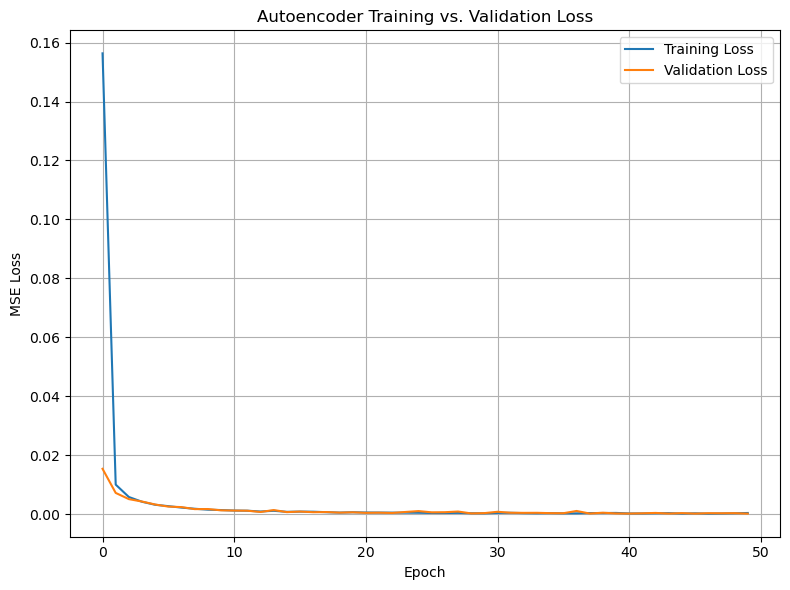

In [104]:
# 2) Plot the curves
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'],   label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training vs. Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Train and Test Split 

In [94]:
latent = pd.DataFrame(
    deep_feats, 
    columns=[f"z_{i}" for i in range(deep_feats.shape[1])]
)
X = df.drop(columns=["Longitude","Latitude","datetime","UHI Index"]).values
y = df['UHI Index'].values
X = pd.concat([latent, tabular], axis=1)  # shape (N, L + 12)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)


In [91]:
latent.head()

,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,z_9,...,z_22,z_23,z_24,z_25,z_26,z_27,z_28,z_29,z_30,z_31
0,0.648231,0.793810,0.394799,0.050232,0.697580,0.0,0.375977,0.0,0.922917,0.690385,...,0.578070,0.074628,0.522717,0.0,0.776113,0.659626,0.291013,0.275986,0.065216,0.204889
1,0.648231,0.793810,0.394799,0.050232,0.697580,0.0,0.375977,0.0,0.922917,0.690385,...,0.578070,0.074628,0.522717,0.0,0.776113,0.659626,0.291013,0.275986,0.065216,0.204889
2,1.179601,0.815546,0.351366,0.211691,0.457680,0.0,0.494496,0.0,1.000167,0.597382,...,0.385715,0.036504,1.207454,0.0,0.584567,1.159155,0.269579,0.333032,0.375367,0.238644
3,1.183112,0.806977,0.369489,0.219263,0.432674,0.0,0.469190,0.0,0.990191,0.593977,...,0.398809,0.045710,1.254851,0.0,0.578816,1.171378,0.244183,0.331392,0.368777,0.227140
4,1.107938,0.799440,0.445089,0.263994,0.416890,0.0,0.409537,0.0,0.949795,0.468132,...,0.308255,0.021895,1.240842,0.0,0.550140,1.194831,0.212672,0.288557,0.413125,0.123905


### Feature Scaling 

In [ ]:
# Scale the training and test data using standardscaler
#sc = StandardScaler()
#X_train = sc.fit_transform(X_train)
#X_test = sc.transform(X_test)

### Model Training

In [95]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
def objective(trial):
    # 1) Suggest hyperparameters
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",           # <— early‐stop metric
        "tree_method": "hist",
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 5e-2, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 9),
        "subsample": trial.suggest_float("subsample", 0.25, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.001, 100, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.001, 100, log=True),
        "early_stopping_rounds": 10,     # <— no improvement → stop
        "device":"cuda",
        "sampling_method":"gradient_based",
        "verbosity": 2,
    }

    # 2) Instantiate & fit
    model = XGBRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    # 3) Compute R² on test set (this is what we maximize)
    preds = model.predict(X_test)
    return r2_score(y_test, preds)

# 4) Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, timeout=600)

print("Best R²:", study.best_value)
print("Best params:", study.best_params)

[I 2025-04-29 10:51:03,742] A new study created in memory with name: no-name-6bd1a643-66f8-48bc-81d3-f7a02b8851cd
[I 2025-04-29 10:51:04,730] Trial 0 finished with value: 0.33670007832578763 and parameters: {'n_estimators': 100, 'learning_rate': 0.13935761453717035, 'max_depth': 2, 'subsample': 0.4866875259268302, 'colsample_bytree': 0.6207637842029847, 'reg_alpha': 0.010923399836383255, 'reg_lambda': 2.428410445809082}. Best is trial 0 with value: 0.33670007832578763.
[I 2025-04-29 10:51:05,537] Trial 1 finished with value: 0.3625102548265585 and parameters: {'n_estimators': 400, 'learning_rate': 0.15845289457116268, 'max_depth': 5, 'subsample': 0.6425284087603674, 'colsample_bytree': 0.518946282957866, 'reg_alpha': 2.097793605769415, 'reg_lambda': 0.08729942535826515}. Best is trial 1 with value: 0.3625102548265585.
[I 2025-04-29 10:51:06,629] Trial 2 finished with value: 0.3904997615904977 and parameters: {'n_estimators': 900, 'learning_rate': 0.16515326080540205, 'max_depth': 2, 's

Best R²: 0.659795190691765
Best params: {'n_estimators': 900, 'learning_rate': 0.0687549240894576, 'max_depth': 7, 'subsample': 0.7025450557813909, 'colsample_bytree': 0.8402213295667645, 'reg_alpha': 0.015325899003689239, 'reg_lambda': 0.8948652934098258}


In [96]:
import xgboost as xgb
from xgboost import XGBRegressor

# … after study.optimize(…) …
best_trial = study.best_trial

print("  Value: {}".format(best_trial.value))
print("  Params: ")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

# Try to grab the fitted sklearn XGBRegressor from the trial:
final_model = best_trial.user_attrs.get("model", None)

if final_model is None:
    print("Best model not saved.  Re-training using best parameters…")

    # 1) Pull out the best params
    best_params = best_trial.params.copy()
    best_params.update({
        "objective":   "reg:squarederror",
        "tree_method": "hist",
        "eval_metric": "rmse",
        "verbosity":   0        
    })

    # 2) Re‐instantiate and fit on the full training set:
    final_model = XGBRegressor(**best_params)
    final_model.fit(X_train, y_train)

print("Best model is ready.")




  Value: 0.659795190691765
  Params: 
    n_estimators: 900
    learning_rate: 0.0687549240894576
    max_depth: 7
    subsample: 0.7025450557813909
    colsample_bytree: 0.8402213295667645
    reg_alpha: 0.015325899003689239
    reg_lambda: 0.8948652934098258
Best model not saved.  Re-training using best parameters…
Best model is ready.


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

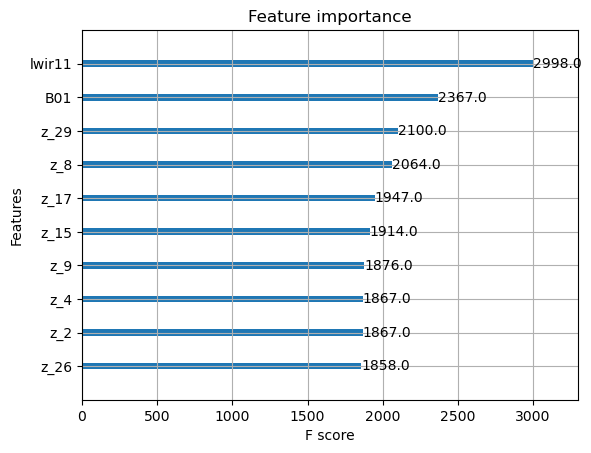

In [102]:
from xgboost import plot_importance
plot_importance(final_model, max_num_features=10)

## Model Evaluation

<p align="justify">Now that we have trained our model, the next step is to evaluate its performance. For evaluation, we will use the R² score, a common metric for regression models that measures how well the model explains the variance in the response variable (UHI index). Scikit-learn provides many other metrics that can be used for evaluation, and you can also write custom code for more specific evaluation needs.</p>


### In-Sample Evaluation
<p align="justify">We will be evaluating our model's performance using the R² score on the training data. It is important to note that this is in-sample performance testing, which involves evaluating the model on the training dataset. These metrics are not truly indicative of the model's ability to generalize. You should reserve testing on the test data before drawing final conclusions about your model's performance.</p>


<p align="justify">In this section, we make predictions on the training set and store them in the <b><i>insample_predictions</i></b> variable. The R² score is then calculated to gauge the model's performance on the training data. It is important to keep in mind that this evaluation is for the training set, and further testing on the test set is necessary to assess the model's generalizability.</p>


In [98]:
# Assuming `model` is an XGBRegressor already .fit(...)
# 1) In‐sample (training) predictions

# you can now do:
insample_preds  = final_model.predict(X_train)


In [99]:
# calculate R-squared score for in-sample predictions
Y_train = y_train.tolist()
r2_score(Y_train, insample_preds)

0.995102047920227

### Out-Sample Evaluation

When evaluating a machine learning model, it is essential to correctly and fairly evaluate the model's ability to generalize. This is because models have a tendency to overfit the dataset they are trained on. To estimate the out-of-sample performance, we will predict on the test data now. 

In [100]:
# Make predictions on the test data
outsample_preds = final_model.predict(X_test)

In [101]:
# calculate R-squared score for out-sample predictions
Y_test = y_test.tolist()
r2_score(Y_test, outsample_preds)

0.6605033278465271

## Submission

Once you are satisfied with your model, you can proceed to make a submission. To do this, you will need to use your model to predict the Urban Heat Island (UHI) index for a set of test coordinates provided in the <b>"Submission_template.csv"</b> file and upload the results to the challenge platform.

In [65]:
#Reading the coordinates for the submission
test_file = pd.read_csv('DSCI-498-main/Examples/Submission_template.csv')
test_file.head()

,Longitude,Latitude,UHI Index
0,-73.971665,40.788763,NaN
1,-73.971928,40.788875,NaN
2,-73.967080,40.789080,NaN
3,-73.972550,40.789082,NaN
4,-73.969697,40.787953,NaN


In [68]:
# Mapping satellite data for submission.
val_data = map_raster_to_coords('Sentinel_Data.tiff', 'Dataset/Submission_template.csv')

Mapping raster values: 100%|██████████| 1040/1040 [00:10<00:00, 97.03it/s]


In [ ]:
val_data, idx_dict = band_indices.compute_indices(val_data)
val_data = classify_water_two_step(val_data, thresh_nsh=0, thresh_sh=0, col_name="is_water")
val_data = classify_water_two_step(val_data, thresh_nsh=0.0, thresh_sh=0.0)

In [ ]:
val_data.head()

In [ ]:
# Extracting specific columns (B01, B06, and NDVI) from the validation dataset
submission_val_data=val_data.loc[:,["B01", "B02", "B03", "B04", "B08", 
        "B11", "B12", "ARVI", "ABEI", 
        "AWEI_nsh", "AWEI_sh", "classification", "is_water", "TIRS-1"]]
submission_val_data.head()

In [ ]:
# Feature Scaling 
#submission_val_data = submission_val_data.values
#transformed_submission_data = sc.transform(submission_val_data)

In [ ]:
#Making predictions
#final_predictions = model.predict(transformed_submission_data)
final_predictions = final_model.predict(submission_val_data)
final_prediction_series = pd.Series(final_predictions)

In [ ]:
#Combining the results into dataframe
submission_df = pd.DataFrame({'Longitude':test_file['Longitude'].values, 'Latitude':test_file['Latitude'].values, 'UHI Index':final_prediction_series.values})

In [ ]:
#Displaying the sample submission dataframe
submission_df.head()

In [ ]:
#Dumping the predictions into a csv file.
submission_df.to_csv("submission.csv",index = False)

In [ ]:
import shap

# Create a TreeExplainer for your model
explainer = shap.Explainer(model)

# Get SHAP values for the test set
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_train, plot_type="bar")



### Upload submission file on platform

Upload the submission.csv on the <a href ="https://challenge.ey.com">platform</a> to get score generated on scoreboard.

## Conclusion

<div align ="justify">Now that you have learned a basic approach to model training, it’s time to try your own approach! Feel free to modify any of the functions presented in this notebook. We look forward to seeing your version of the model and the results. Best of luck with the challenge!</div>